<a href="https://colab.research.google.com/github/Piotr1709/lecture1/blob/main/PUM5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [7]:

# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_5303/957244038.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.
First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [37]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    int64  
 2   Education Level      373 non-null    int64  
 3   Job Title            373 non-null    int64  
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 20.4 KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  200000.0


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [38]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)
X = X.drop("Age", axis=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

               feature        VIF
0                  Age  15.191310
1               Gender   2.059767
2      Education Level   2.403316
3            Job Title   4.865563
4  Years of Experience   9.479247
               feature       VIF
0               Gender  1.819647
1      Education Level  2.379329
2            Job Title  2.798903
3  Years of Experience  4.147387


Spróbuj poprawić wynik używając regresji LASSO

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_regressor = Lasso(alpha=1.0, random_state=42)

lasso_regressor.fit(X_train, y_train)

print(f"Lasso Współczynniki: {lasso_regressor.coef_}")
print(f"Lasso Wyraz wolny: {lasso_regressor.intercept_}")
print(f"Lasso R^2 (trening): {lasso_regressor.score(X_train, y_train):.2f}")
print(f"Lasso Średni błąd absolutny z treningu: {mean_absolute_error(y_train, lasso_regressor.predict(X_train)):.2f}")

y_pred_lasso = lasso_regressor.predict(X_test)

print(f"Lasso Średni błąd kwadratowy (test): {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Lasso Średni błąd absolutny (test): {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"Lasso Wyjaśniona wariancja (test): {explained_variance_score(y_test, y_pred_lasso):.2f}")
print(f"Lasso R^2 (test): {r2_score(y_test, y_pred_lasso):.2f}")

Lasso Współczynniki: [ 5938.97104926 14227.70323444    45.79415999  5841.53666902]
Lasso Wyraz wolny: 27036.79531522107
Lasso R^2 (trening): 0.89
Lasso Średni błąd absolutny z treningu: 11367.64
Lasso Średni błąd kwadratowy (test): 240128021.22
Lasso Średni błąd absolutny (test): 11006.05
Lasso Wyjaśniona wariancja (test): 0.89
Lasso R^2 (test): 0.89


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [59]:
df['Years of Experience Squared'] = df['Years of Experience']**2
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lasso_regressor_squared = Lasso(alpha=1.0, random_state=42)
lasso_regressor_squared.fit(X_train, y_train)
print(f"Lasso Współczynniki: {lasso_regressor_squared.coef_}")
print(f"Lasso Wyraz wolny: {lasso_regressor_squared.intercept_}")
print(f"Lasso R^2 (trening): {lasso_regressor_squared.score(X_train, y_train):.2f}")
print(f"Lasso Średni błąd absolutny z treningu: {mean_absolute_error(y_train, lasso_regressor_squared.predict(X_train)):.2f}")

y_pred_lasso_squared = lasso_regressor_squared.predict(X_test)

print(f"Lasso Średni błąd kwadratowy (test): {mean_squared_error(y_test, y_pred_lasso_squared):.2f}")
print(f"Lasso Średni błąd absolutny (test): {mean_absolute_error(y_test, y_pred_lasso_squared):.2f}")
print(f"Lasso Wyjaśniona wariancja (test): {explained_variance_score(y_test, y_pred_lasso_squared):.2f}")
print(f"Lasso R^2 (test): {r2_score(y_test, y_pred_lasso_squared):.2f}")

Lasso Współczynniki: [ 3266.82496733  7577.9602064  15365.52346093    28.57686235
  2845.41215504   -24.28577896]
Lasso Wyraz wolny: -61675.12339581981
Lasso R^2 (trening): 0.90
Lasso Średni błąd absolutny z treningu: 11065.06
Lasso Średni błąd kwadratowy (test): 253409876.34
Lasso Średni błąd absolutny (test): 11266.56
Lasso Wyjaśniona wariancja (test): 0.89
Lasso R^2 (test): 0.89


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

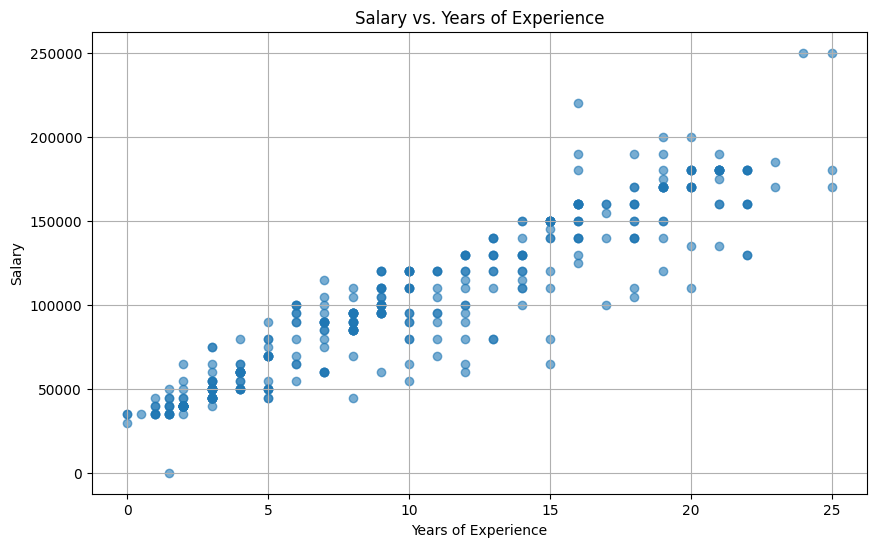

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.6)
plt.title('Salary vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

    Age  Gender  Education Level  Job Title  Years of Experience    Salary  \
0  32.0       1                0        159                  5.0   90000.0   
1  28.0       0                1         17                  3.0   65000.0   
2  45.0       1                2        130                 15.0  150000.0   
3  36.0       0                0        101                  7.0   60000.0   
4  52.0       1                1         22                 20.0  200000.0   

   Years of Experience Squared  Years of Experience cubed  
0                         25.0                      125.0  
1                          9.0                       27.0  
2                        225.0                     3375.0  
3                         49.0                      343.0  
4                        400.0                     8000.0  
--- K-NN (single feature) with weights='uniform' ---
K-NN Średni błąd kwadratowy (test): 324555558.04
K-NN Średni błąd absolutny (test): 12836.16
K-NN Wyjaśniona wariancja

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


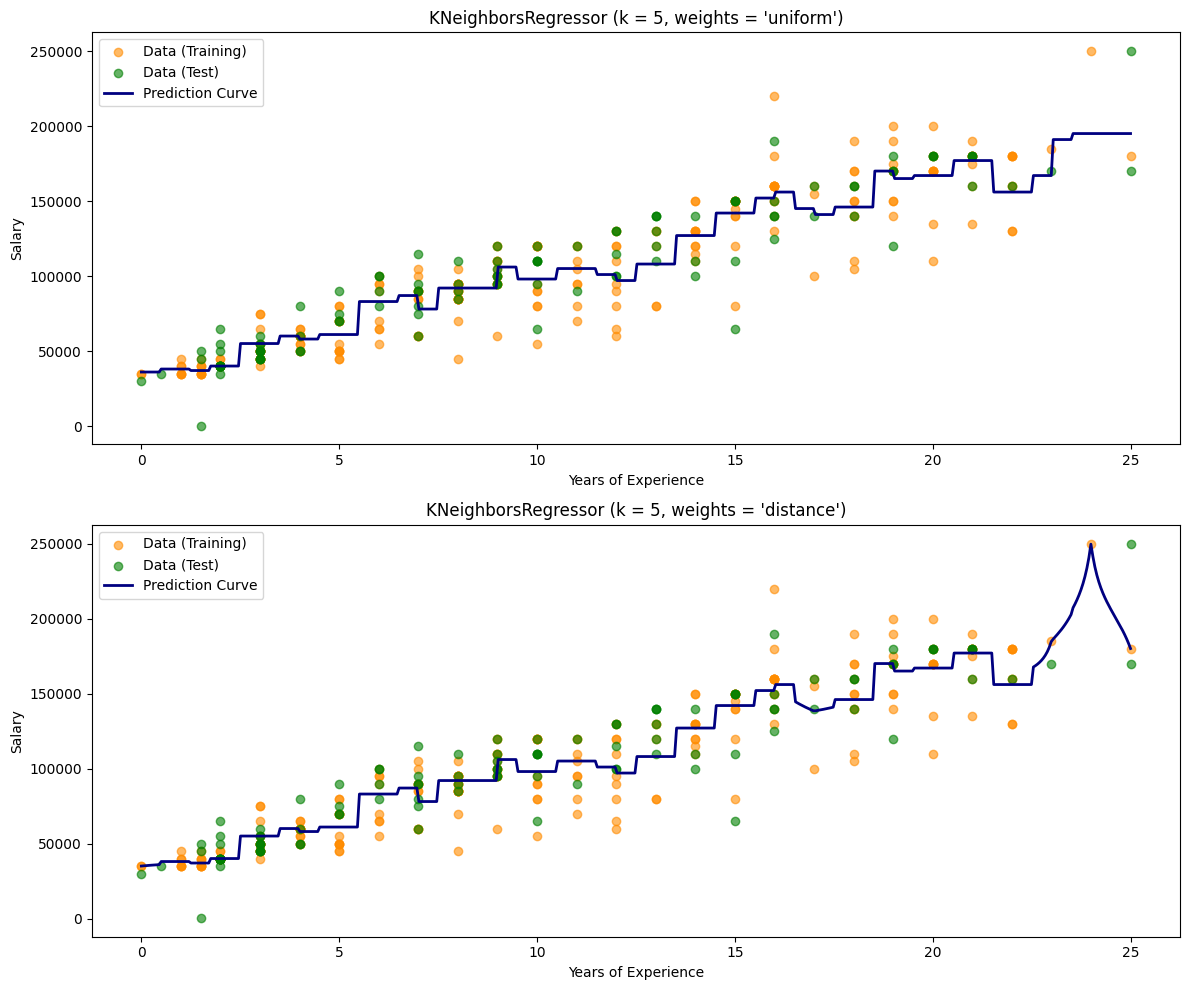

In [73]:
from sklearn import neighbors
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

df.dropna(inplace=True)
print(df.head())

y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

years_exp_min = df['Years of Experience'].min()
years_exp_max = df['Years of Experience'].max()
X_plot = np.linspace(years_exp_min, years_exp_max, 500).reshape(-1, 1)

n_neighbors = 5

plt.figure(figsize=(12, 10))

for i, weights in enumerate(["uniform", "distance"]):
    X_knn_train = X_train[['Years of Experience']]
    y_knn_train = y_train
    knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)

    knn.fit(X_knn_train, y_knn_train)

    y_pred_plot = knn.predict(X_plot)

    X_test_years_exp = X_test[['Years of Experience']]
    y_pred_test_single_feature = knn.predict(X_test_years_exp)
    r2_score_knn = r2_score(y_test, y_pred_test_single_feature)

    plt.subplot(2, 1, i + 1)
    plt.scatter(X_knn_train, y_knn_train, color="darkorange", label="Data (Training)", alpha=0.6)
    plt.scatter(X_test_years_exp, y_test, color="green", label="Data (Test)", alpha=0.6)
    plt.plot(X_plot, y_pred_plot, color="navy", label="Prediction Curve", linewidth=2)
    plt.legend()
    plt.title(f"KNeighborsRegressor (k = {n_neighbors}, weights = '{weights}')")
    plt.xlabel("Years of Experience")
    plt.ylabel("Salary")

    print(f"--- K-NN (single feature) with weights='{weights}' ---")
    print(f"K-NN Średni błąd kwadratowy (test): {mean_squared_error(y_test, y_pred_test_single_feature):.2f}")
    print(f"K-NN Średni błąd absolutny (test): {mean_absolute_error(y_test, y_pred_test_single_feature):.2f}")
    print(f"K-NN Wyjaśniona wariancja (test): {explained_variance_score(y_test, y_pred_test_single_feature):.2f}")
    print(f"K-NN R^2 (test): {r2_score_knn:.2f}")
    print("\n")

plt.tight_layout()
plt.show()

In [74]:
df['Years of Experience cubed'] = df['Years of Experience']**3
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lasso_regressor_squared = Lasso(alpha=1.0, random_state=42)
lasso_regressor_squared.fit(X_train, y_train)
print(f"Lasso Współczynniki: {lasso_regressor_squared.coef_}")
print(f"Lasso Wyraz wolny: {lasso_regressor_squared.intercept_}")
print(f"Lasso R^2 (trening): {lasso_regressor_squared.score(X_train, y_train):.2f}")
print(f"Lasso Średni błąd absolutny z treningu: {mean_absolute_error(y_train, lasso_regressor_squared.predict(X_train)):.2f}")

y_pred_lasso_squared = lasso_regressor_squared.predict(X_test)

print(f"Lasso Średni błąd kwadratowy (test): {mean_squared_error(y_test, y_pred_lasso_squared):.2f}")
print(f"Lasso Średni błąd absolutny (test): {mean_absolute_error(y_test, y_pred_lasso_squared):.2f}")
print(f"Lasso Wyjaśniona wariancja (test): {explained_variance_score(y_test, y_pred_lasso_squared):.2f}")
print(f"Lasso R^2 (test): {r2_score(y_test, y_pred_lasso_squared):.2f}")

Lasso Współczynniki: [ 3.24922397e+03  7.55793217e+03  1.54836509e+04  2.91681449e+01
  3.32015601e+03 -7.51721272e+01  1.48697529e+00]
Lasso Wyraz wolny: -62144.73994970495
Lasso R^2 (trening): 0.90
Lasso Średni błąd absolutny z treningu: 11062.34
Lasso Średni błąd kwadratowy (test): 249309152.04
Lasso Średni błąd absolutny (test): 11210.39
Lasso Wyjaśniona wariancja (test): 0.89
Lasso R^2 (test): 0.89


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.899e+10, tolerance: 6.127e+07
  model = cd_fast.enet_coordinate_descent(


Błędy modelów testowych:
Regresja Liniowa: 11,377.18
Regresja Lasso: 11,006.05
Regresja Lasso 2 stopnia: 11,266.56
Regresja Lasso 3 stopnia: 11,210.39
KNN:
Wagi 'uniform': 12,836.16
Wagi 'distance': 12,803.42

